# Gas Emission Analysis and Visualization

This notebook provides comprehensive visualization and analysis of gas emission data from livestock facilities. We analyze three key gases:
- **NH₃ (Ammonia)**: Air quality indicator
- **CH₄ (Methane)**: Greenhouse gas
- **CO₂ (Carbon Dioxide)**: Greenhouse gas and ventilation tracer

The analysis includes:
- Time series visualization of emission rates
- Ventilation rate analysis
- Gas concentration differences
- Daily emission patterns
- Correlation analysis
- Summary statistics

## Data Source
The emission data is generated from the `simple_gas_analysis.py` script which processes raw sensor measurements to calculate emission rates (g/h) for both North and South sides of the facility.

In [1]:
# Import Required Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from datetime import datetime
import warnings

# Set up plotting style
plt.style.use('default')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")
print("Ready for gas emission analysis and visualization")

✅ Libraries imported successfully!
📊 Ready for gas emission analysis and visualization


## 1. Load and Prepare Emission Data

First, we'll load the processed emission data from our analysis and prepare it for visualization.

In [2]:
# Load the processed emission data
data_file = "20250408-15_ringversuche_emission_combined_data.csv"

try:
    # Load data and prepare datetime
    df = pd.read_csv(data_file)
    df['DATE.TIME'] = pd.to_datetime(df['DATE.TIME'])
    df['hour'] = df['DATE.TIME'].dt.hour
    
    print(f"Data loaded successfully!")
    print(f"Dataset shape: {df.shape}")
    print(f"Date range: {df['DATE.TIME'].min()} to {df['DATE.TIME'].max()}")
    print(f"Average number of animals: {df['n_animals'].mean():.1f}")
    
    # Display basic info about the data
    print("\nKey columns available:")
    emission_cols = [col for col in df.columns if col.startswith('e_')]
    print(f"Emission rates: {emission_cols}")
    
    # Show first few rows
    print("\nSample data:")
    display_cols = ['DATE.TIME', 'Temperature', 'n_animals', 'e_NH3_N', 'e_CH4_N', 'e_CO2_N']
    print(df[display_cols].head())
    
except FileNotFoundError:
    print(f"File not found: {data_file}")
    print("Please run the emission analysis script first to generate the data file.")
except Exception as e:
    print(f"Error loading data: {str(e)}")

✅ Data loaded successfully!
📊 Dataset shape: (1311, 47)
📅 Date range: 2025-04-08 12:00:00 to 2025-04-15 23:00:00
🐄 Average number of animals: 48.6

📋 Key columns available:
Emission rates: ['e_NH3_N', 'e_NH3_S', 'e_CH4_N', 'e_CH4_S', 'e_CO2_N', 'e_CO2_S']

📝 Sample data:
            DATE.TIME  Temperature  n_animals    e_NH3_N      e_CH4_N  \
0 2025-04-08 12:00:00    18.210000       42.5  59.009099  1051.101414   
1 2025-04-08 13:00:00    18.670000       43.0  53.329043  1079.857545   
2 2025-04-08 14:00:00    14.423333       40.5  57.280986  1123.097587   
3 2025-04-08 15:00:00    14.645833       43.0  75.133206  1125.105526   
4 2025-04-08 16:00:00    15.299167       45.0  38.204075  1151.393778   

        e_CO2_N  
0  28262.963703  
1  30501.544870  
2  30498.939586  
3  32685.584749  
4  33507.945176  


## 2. Gas Emission Overview

Let's create comprehensive time series plots showing emission rates for all three gases (NH₃, CH₄, CO₂) on both North and South sides of the facility.

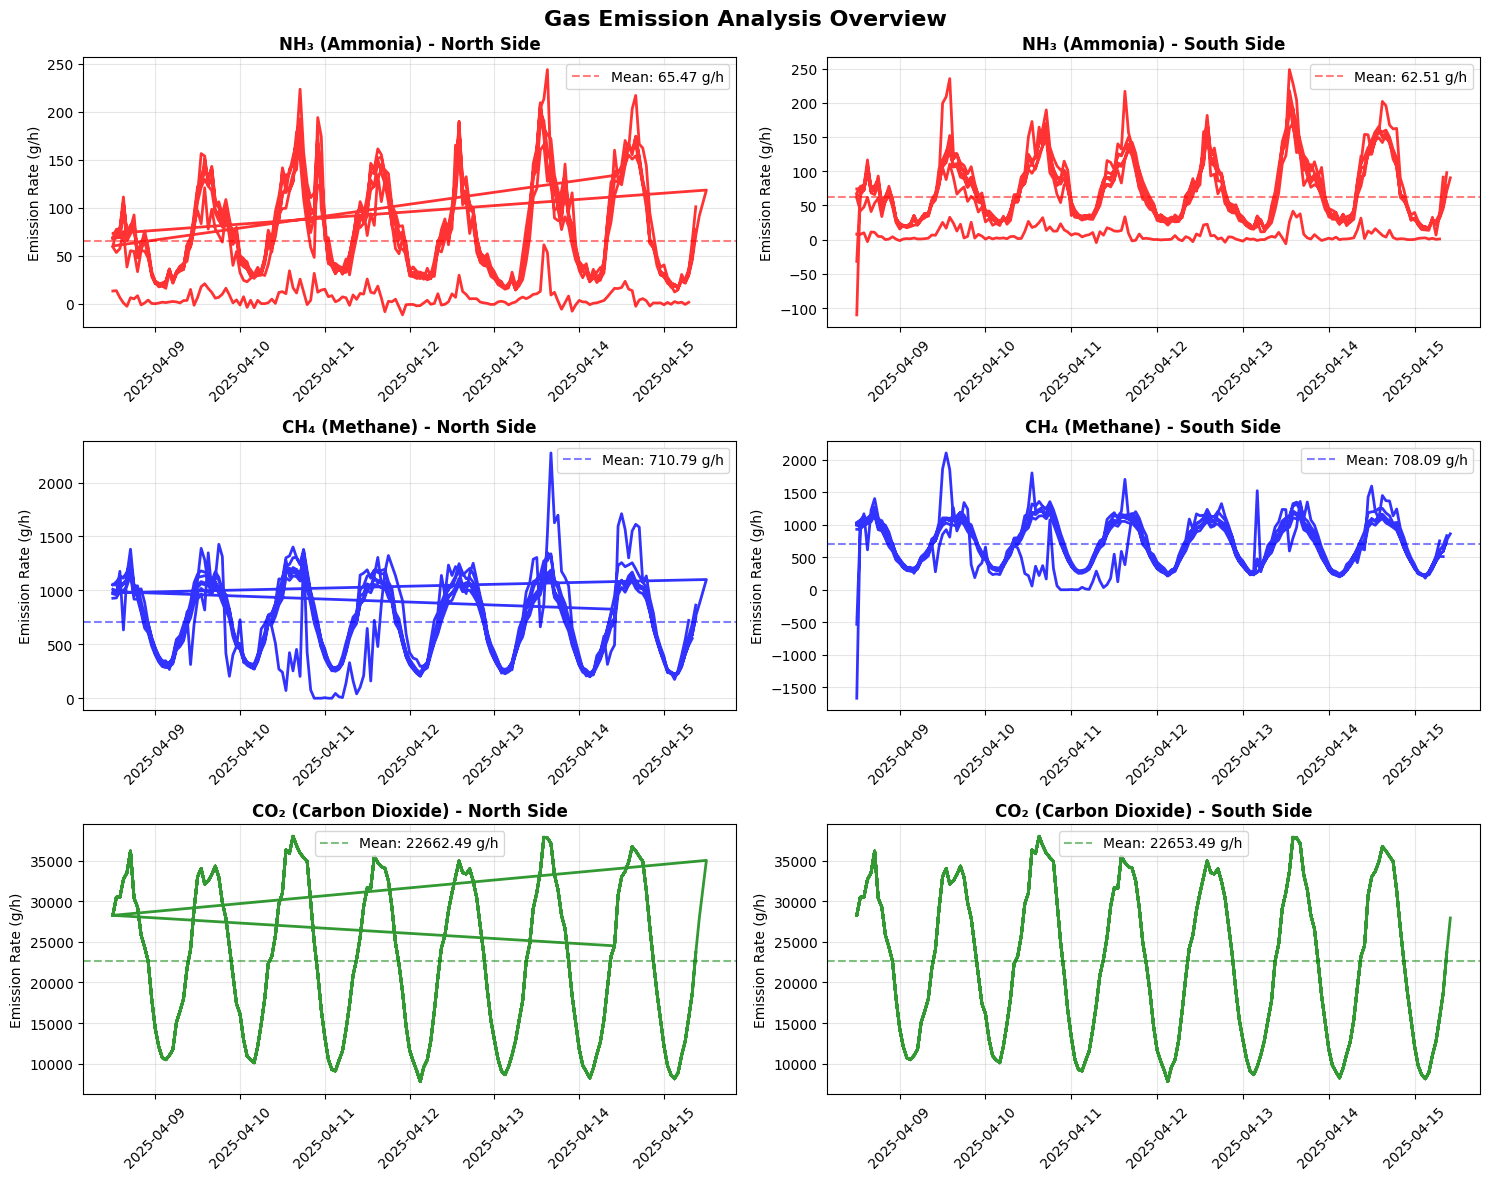

📊 Emission Summary Statistics:
NH3: North=65.47 g/h, South=62.51 g/h, Total=127.98 g/h
CH4: North=710.79 g/h, South=708.09 g/h, Total=1418.88 g/h
CO2: North=22662.49 g/h, South=22653.49 g/h, Total=45315.98 g/h


In [3]:
# Create emission overview plots
fig, axes = plt.subplots(3, 2, figsize=(15, 12))
fig.suptitle('Gas Emission Analysis Overview', fontsize=16, fontweight='bold')

gases = ['NH3', 'CH4', 'CO2']
colors = ['red', 'blue', 'green']
gas_names = ['NH₃ (Ammonia)', 'CH₄ (Methane)', 'CO₂ (Carbon Dioxide)']

for i, gas in enumerate(gases):
    # North side emissions
    axes[i, 0].plot(df['DATE.TIME'], df[f'e_{gas}_N'], 
                   color=colors[i], linewidth=2, alpha=0.8)
    axes[i, 0].set_title(f'{gas_names[i]} - North Side', fontsize=12, fontweight='bold')
    axes[i, 0].set_ylabel('Emission Rate (g/h)')
    axes[i, 0].grid(True, alpha=0.3)
    axes[i, 0].tick_params(axis='x', rotation=45)
    
    # Add some statistics
    mean_val = df[f'e_{gas}_N'].mean()
    axes[i, 0].axhline(y=mean_val, color=colors[i], linestyle='--', alpha=0.5, 
                      label=f'Mean: {mean_val:.2f} g/h')
    axes[i, 0].legend()
    
    # South side emissions
    axes[i, 1].plot(df['DATE.TIME'], df[f'e_{gas}_S'], 
                   color=colors[i], linewidth=2, alpha=0.8)
    axes[i, 1].set_title(f'{gas_names[i]} - South Side', fontsize=12, fontweight='bold')
    axes[i, 1].set_ylabel('Emission Rate (g/h)')
    axes[i, 1].grid(True, alpha=0.3)
    axes[i, 1].tick_params(axis='x', rotation=45)
    
    # Add some statistics
    mean_val = df[f'e_{gas}_S'].mean()
    axes[i, 1].axhline(y=mean_val, color=colors[i], linestyle='--', alpha=0.5, 
                      label=f'Mean: {mean_val:.2f} g/h')
    axes[i, 1].legend()

plt.tight_layout()
plt.savefig('emission_overview.png', dpi=300, bbox_inches='tight')
plt.show()

# Print summary statistics
print("Emission Summary Statistics:")
for gas in gases:
    north_mean = df[f'e_{gas}_N'].mean()
    south_mean = df[f'e_{gas}_S'].mean()
    total_mean = north_mean + south_mean
    print(f"{gas}: North={north_mean:.2f} g/h, South={south_mean:.2f} g/h, Total={total_mean:.2f} g/h")

## 3. Ventilation Rate Analysis

Ventilation rates are crucial for understanding air exchange in the facility. Let's analyze the CO₂-based ventilation rates for both sides.

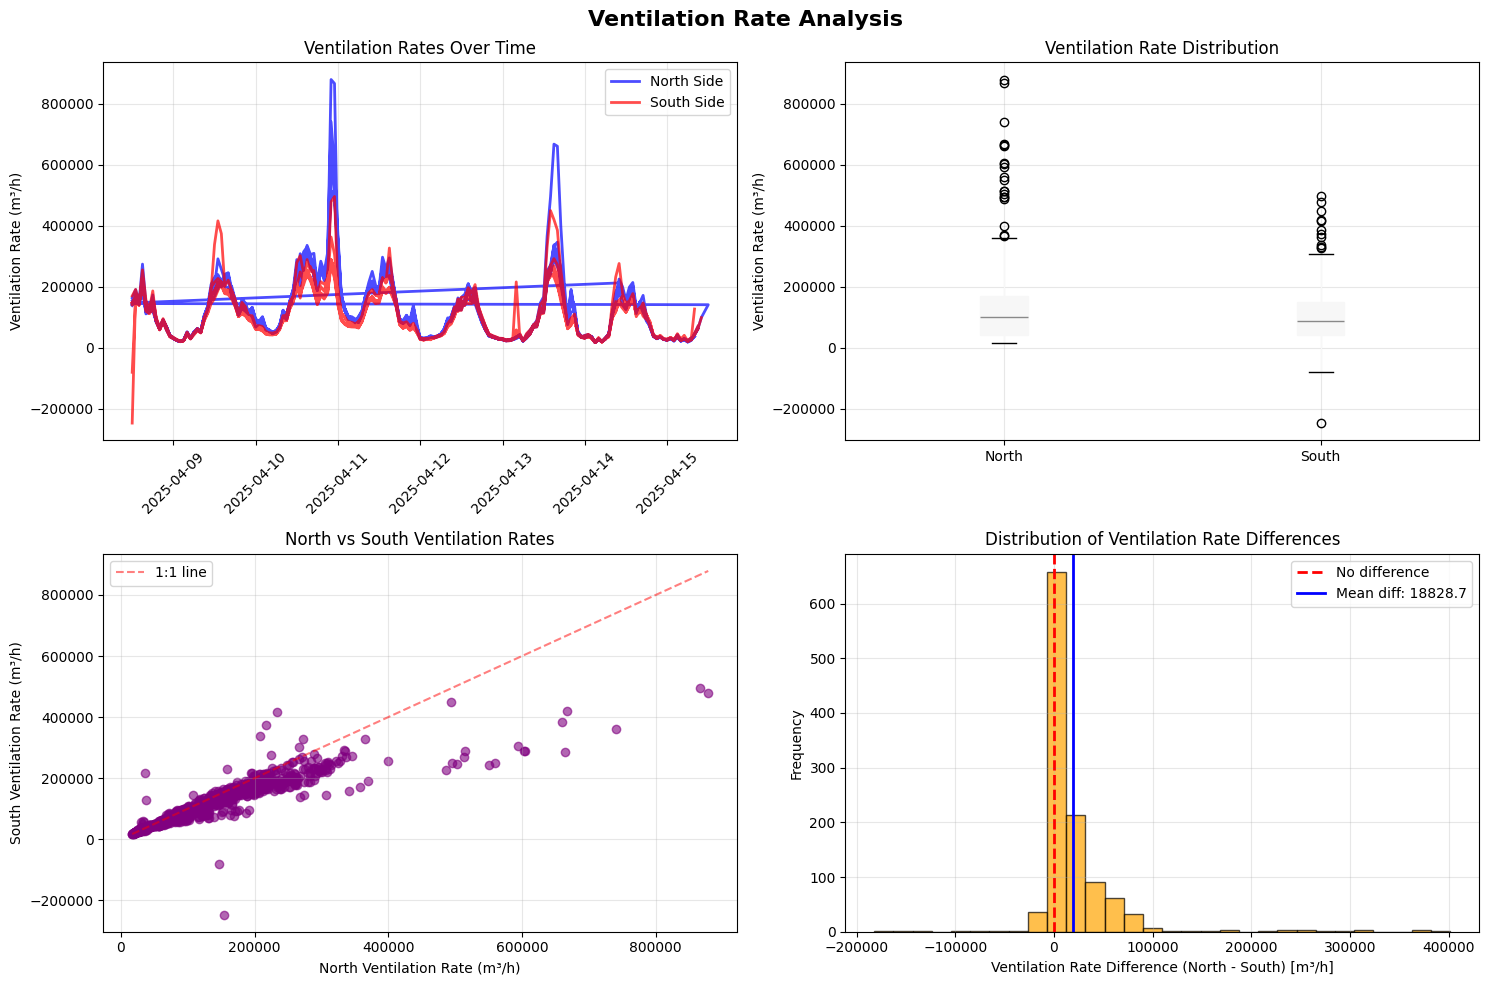

🌬️ Ventilation Rate Statistics:
North Side - Mean: 122059.8 m³/h, Std: 100907.8 m³/h
South Side - Mean: 103209.5 m³/h, Std: 73340.7 m³/h
Average Difference (N-S): 18828.7 ± 45703.0 m³/h


In [4]:
# Ventilation rate analysis
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Ventilation Rate Analysis', fontsize=16, fontweight='bold')

# Time series plot
axes[0, 0].plot(df['DATE.TIME'], df['Q_Vent_rate_N'], 
               color='blue', linewidth=2, label='North Side', alpha=0.7)
axes[0, 0].plot(df['DATE.TIME'], df['Q_Vent_rate_S'], 
               color='red', linewidth=2, label='South Side', alpha=0.7)
axes[0, 0].set_title('Ventilation Rates Over Time')
axes[0, 0].set_ylabel('Ventilation Rate (m³/h)')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].tick_params(axis='x', rotation=45)

# Comparison boxplot
vent_data = pd.DataFrame({
    'North': df['Q_Vent_rate_N'],
    'South': df['Q_Vent_rate_S']
})
vent_data.boxplot(ax=axes[0, 1], patch_artist=True)
axes[0, 1].set_title('Ventilation Rate Distribution')
axes[0, 1].set_ylabel('Ventilation Rate (m³/h)')
axes[0, 1].grid(True, alpha=0.3)

# Scatter plot: North vs South ventilation rates
axes[1, 0].scatter(df['Q_Vent_rate_N'], df['Q_Vent_rate_S'], alpha=0.6, color='purple')
axes[1, 0].plot([df['Q_Vent_rate_N'].min(), df['Q_Vent_rate_N'].max()], 
               [df['Q_Vent_rate_N'].min(), df['Q_Vent_rate_N'].max()], 
               'r--', alpha=0.5, label='1:1 line')
axes[1, 0].set_xlabel('North Ventilation Rate (m³/h)')
axes[1, 0].set_ylabel('South Ventilation Rate (m³/h)')
axes[1, 0].set_title('North vs South Ventilation Rates')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Histogram of ventilation rate differences
vent_diff = df['Q_Vent_rate_N'] - df['Q_Vent_rate_S']
axes[1, 1].hist(vent_diff, bins=30, alpha=0.7, color='orange', edgecolor='black')
axes[1, 1].axvline(x=0, color='red', linestyle='--', linewidth=2, label='No difference')
axes[1, 1].axvline(x=vent_diff.mean(), color='blue', linestyle='-', linewidth=2, 
                  label=f'Mean diff: {vent_diff.mean():.1f}')
axes[1, 1].set_xlabel('Ventilation Rate Difference (North - South) [m³/h]')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title('Distribution of Ventilation Rate Differences')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('ventilation_rates.png', dpi=300, bbox_inches='tight')
plt.show()

# Print ventilation statistics
print("Ventilation Rate Statistics:")
print(f"North Side - Mean: {df['Q_Vent_rate_N'].mean():.1f} m³/h, Std: {df['Q_Vent_rate_N'].std():.1f} m³/h")
print(f"South Side - Mean: {df['Q_Vent_rate_S'].mean():.1f} m³/h, Std: {df['Q_Vent_rate_S'].std():.1f} m³/h")
print(f"Average Difference (N-S): {vent_diff.mean():.1f} ± {vent_diff.std():.1f} m³/h")

## 4. Gas Concentration Differences

The concentration differences (inlet - outlet) directly indicate emission sources and patterns.

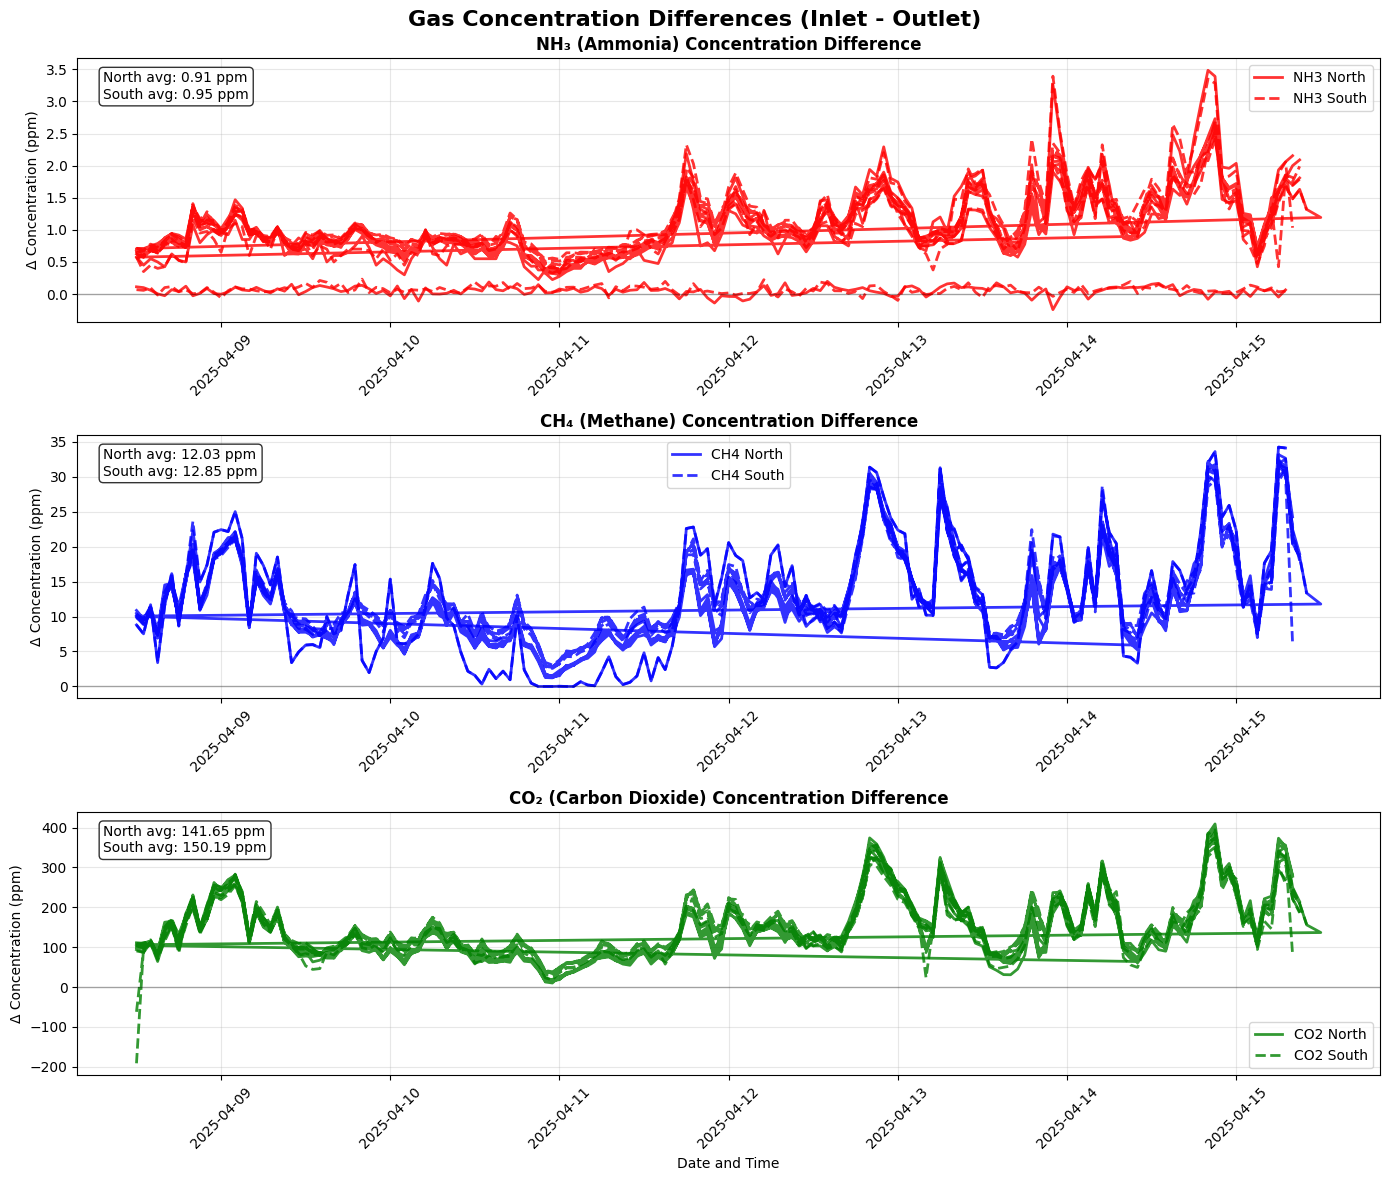

📈 Concentration Difference Statistics:
NH3: North Δ=0.905 ppm, South Δ=0.955 ppm
CH4: North Δ=12.033 ppm, South Δ=12.852 ppm
CO2: North Δ=141.651 ppm, South Δ=150.187 ppm


In [5]:
# Gas concentration differences
fig, axes = plt.subplots(3, 1, figsize=(14, 12))
fig.suptitle('Gas Concentration Differences (Inlet - Outlet)', fontsize=16, fontweight='bold')

gases = ['NH3', 'CH4', 'CO2']
colors = ['red', 'blue', 'green']
gas_names = ['NH₃ (Ammonia)', 'CH₄ (Methane)', 'CO₂ (Carbon Dioxide)']

for i, gas in enumerate(gases):
    # Plot both North and South concentration differences
    axes[i].plot(df['DATE.TIME'], df[f'delta_{gas}_N_ppm'], 
                color=colors[i], linewidth=2, label=f'{gas} North', alpha=0.8)
    axes[i].plot(df['DATE.TIME'], df[f'delta_{gas}_S_ppm'], 
                color=colors[i], linewidth=2, linestyle='--', label=f'{gas} South', alpha=0.8)
    
    axes[i].set_title(f'{gas_names[i]} Concentration Difference', fontsize=12, fontweight='bold')
    axes[i].set_ylabel('Δ Concentration (ppm)')
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)
    axes[i].tick_params(axis='x', rotation=45)
    
    # Add zero line for reference
    axes[i].axhline(y=0, color='black', linestyle='-', alpha=0.3, linewidth=1)
    
    # Add statistics
    north_mean = df[f'delta_{gas}_N_ppm'].mean()
    south_mean = df[f'delta_{gas}_S_ppm'].mean()
    axes[i].text(0.02, 0.95, f'North avg: {north_mean:.2f} ppm\nSouth avg: {south_mean:.2f} ppm', 
                transform=axes[i].transAxes, verticalalignment='top', 
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

axes[-1].set_xlabel('Date and Time')
plt.tight_layout()
plt.savefig('concentration_differences.png', dpi=300, bbox_inches='tight')
plt.show()

# Print concentration difference statistics
print("Concentration Difference Statistics:")
for gas in gases:
    north_mean = df[f'delta_{gas}_N_ppm'].mean()
    south_mean = df[f'delta_{gas}_S_ppm'].mean()
    print(f"{gas}: North Δ={north_mean:.3f} ppm, South Δ={south_mean:.3f} ppm")

## 5. Daily Emission Patterns

Let's analyze how emissions vary throughout the day to identify patterns related to animal behavior and environmental conditions.

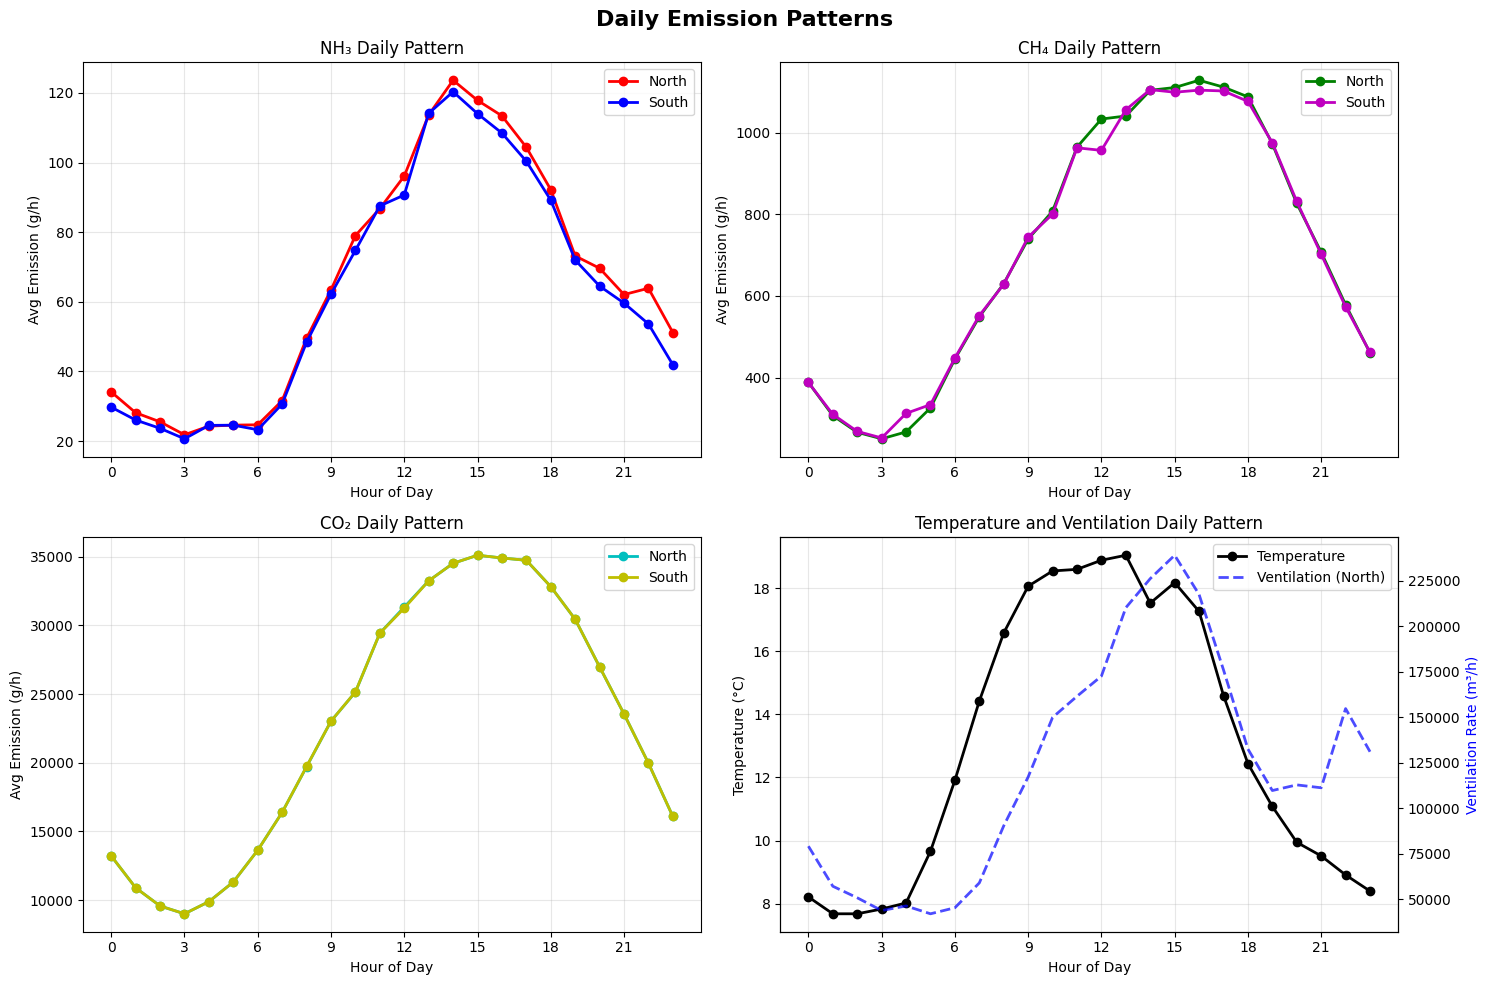

🕐 Daily Pattern Analysis:
NH3: Peak hours - North: 14.0:00, South: 14.0:00
CH4: Peak hours - North: 16.0:00, South: 14.0:00
CO2: Peak hours - North: 15.0:00, South: 15.0:00
Temperature: Peak hour - 13.0:00


In [6]:
# Daily emission patterns analysis
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Daily Emission Patterns', fontsize=16, fontweight='bold')

# Group data by hour for average patterns
hourly_avg = df.groupby('hour').agg({
    'e_NH3_N': 'mean', 'e_NH3_S': 'mean',
    'e_CH4_N': 'mean', 'e_CH4_S': 'mean',
    'e_CO2_N': 'mean', 'e_CO2_S': 'mean',
    'Temperature': 'mean',
    'Q_Vent_rate_N': 'mean', 'Q_Vent_rate_S': 'mean'
}).reset_index()

# NH3 daily pattern
axes[0, 0].plot(hourly_avg['hour'], hourly_avg['e_NH3_N'], 
               'ro-', label='North', linewidth=2, markersize=6)
axes[0, 0].plot(hourly_avg['hour'], hourly_avg['e_NH3_S'], 
               'bo-', label='South', linewidth=2, markersize=6)
axes[0, 0].set_title('NH₃ Daily Pattern')
axes[0, 0].set_ylabel('Avg Emission (g/h)')
axes[0, 0].set_xlabel('Hour of Day')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].set_xticks(range(0, 24, 3))

# CH4 daily pattern
axes[0, 1].plot(hourly_avg['hour'], hourly_avg['e_CH4_N'], 
               'go-', label='North', linewidth=2, markersize=6)
axes[0, 1].plot(hourly_avg['hour'], hourly_avg['e_CH4_S'], 
               'mo-', label='South', linewidth=2, markersize=6)
axes[0, 1].set_title('CH₄ Daily Pattern')
axes[0, 1].set_ylabel('Avg Emission (g/h)')
axes[0, 1].set_xlabel('Hour of Day')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].set_xticks(range(0, 24, 3))

# CO2 daily pattern
axes[1, 0].plot(hourly_avg['hour'], hourly_avg['e_CO2_N'], 
               'co-', label='North', linewidth=2, markersize=6)
axes[1, 0].plot(hourly_avg['hour'], hourly_avg['e_CO2_S'], 
               'yo-', label='South', linewidth=2, markersize=6)
axes[1, 0].set_title('CO₂ Daily Pattern')
axes[1, 0].set_ylabel('Avg Emission (g/h)')
axes[1, 0].set_xlabel('Hour of Day')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].set_xticks(range(0, 24, 3))

# Temperature and ventilation pattern
ax_temp = axes[1, 1]
ax_vent = ax_temp.twinx()

line1 = ax_temp.plot(hourly_avg['hour'], hourly_avg['Temperature'], 
                    'ko-', linewidth=2, markersize=6, label='Temperature')
line2 = ax_vent.plot(hourly_avg['hour'], hourly_avg['Q_Vent_rate_N'], 
                    'b--', linewidth=2, alpha=0.7, label='Ventilation (North)')

ax_temp.set_title('Temperature and Ventilation Daily Pattern')
ax_temp.set_xlabel('Hour of Day')
ax_temp.set_ylabel('Temperature (°C)', color='black')
ax_vent.set_ylabel('Ventilation Rate (m³/h)', color='blue')
ax_temp.grid(True, alpha=0.3)
ax_temp.set_xticks(range(0, 24, 3))

# Combine legends
lines1, labels1 = ax_temp.get_legend_handles_labels()
lines2, labels2 = ax_vent.get_legend_handles_labels()
ax_temp.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

plt.tight_layout()
plt.savefig('daily_patterns.png', dpi=300, bbox_inches='tight')
plt.show()

# Print peak hours analysis
print("Daily Pattern Analysis:")
for gas in ['NH3', 'CH4', 'CO2']:
    north_peak_hour = hourly_avg.loc[hourly_avg[f'e_{gas}_N'].idxmax(), 'hour']
    south_peak_hour = hourly_avg.loc[hourly_avg[f'e_{gas}_S'].idxmax(), 'hour']
    print(f"{gas}: Peak hours - North: {north_peak_hour}:00, South: {south_peak_hour}:00")

temp_peak_hour = hourly_avg.loc[hourly_avg['Temperature'].idxmax(), 'hour']
print(f"Temperature: Peak hour - {temp_peak_hour}:00")

## 6. Correlation Analysis

Understanding the relationships between environmental factors, animal parameters, and emission rates helps identify key drivers of emissions.

In [ ]:
# Correlation analysis
# Select key variables for correlation analysis
correlation_vars = [
    'Temperature', 'n_animals', 'm_weight', 'Y1_milk_prod',
    'Q_Vent_rate_N', 'Q_Vent_rate_S',
    'e_NH3_N', 'e_NH3_S', 'e_CH4_N', 'e_CH4_S', 'e_CO2_N', 'e_CO2_S'
]

# Calculate correlation matrix
corr_data = df[correlation_vars].corr()

# Create correlation heatmap
plt.figure(figsize=(14, 12))
mask = np.triu(np.ones_like(corr_data, dtype=bool))  # Mask upper triangle
sns.heatmap(corr_data, mask=mask, annot=True, cmap='RdBu_r', center=0, 
            fmt='.2f', square=True, cbar_kws={'label': 'Correlation Coefficient'},
            linewidths=0.5, cbar=True)
plt.title('Correlation Matrix: Environmental and Emission Variables', 
          fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

# Find strongest correlations
print("Strongest Correlations (|r| > 0.5):")
# Get correlation pairs
correlation_pairs = []
for i in range(len(corr_data.columns)):
    for j in range(i+1, len(corr_data.columns)):
        var1 = corr_data.columns[i]
        var2 = corr_data.columns[j]
        corr_val = corr_data.iloc[i, j]
        if abs(corr_val) > 0.5:
            correlation_pairs.append((var1, var2, corr_val))

# Sort by absolute correlation value
correlation_pairs.sort(key=lambda x: abs(x[2]), reverse=True)

for var1, var2, corr_val in correlation_pairs[:10]:  # Top 10 correlations
    print(f"{var1} ↔ {var2}: r = {corr_val:.3f}")

# Temperature correlation analysis
print("\nTemperature Correlations:")
temp_corrs = corr_data['Temperature'].sort_values(key=abs, ascending=False)[1:]  # Exclude self-correlation
for var, corr_val in temp_corrs.head(5).items():
    print(f"Temperature ↔ {var}: r = {corr_val:.3f}")

## 7. Summary Statistics and Comparisons

Let's create comprehensive summary plots to understand the overall emission characteristics and compare different aspects of the data.

In [ ]:
# Summary statistics and comparisons
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Emission Summary Statistics and Comparisons', fontsize=16, fontweight='bold')

# 1. Total emissions by gas type
gas_totals = {
    'NH₃': df['e_NH3_N'].sum() + df['e_NH3_S'].sum(),
    'CH₄': df['e_CH4_N'].sum() + df['e_CH4_S'].sum(),
    'CO₂': df['e_CO2_N'].sum() + df['e_CO2_S'].sum()
}

bars1 = axes[0, 0].bar(gas_totals.keys(), gas_totals.values(), 
                      color=['red', 'blue', 'green'], alpha=0.7, edgecolor='black')
axes[0, 0].set_title('Total Emissions by Gas Type')
axes[0, 0].set_ylabel('Total Emission (g)')
axes[0, 0].grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bar, value in zip(bars1, gas_totals.values()):
    axes[0, 0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + value*0.01,
                   f'{value:.1f}g', ha='center', va='bottom', fontweight='bold')

# 2. North vs South comparison
sides_data = {
    'North': df['e_NH3_N'].sum() + df['e_CH4_N'].sum() + df['e_CO2_N'].sum(),
    'South': df['e_NH3_S'].sum() + df['e_CH4_S'].sum() + df['e_CO2_S'].sum()
}

bars2 = axes[0, 1].bar(sides_data.keys(), sides_data.values(), 
                      color=['skyblue', 'coral'], alpha=0.7, edgecolor='black')
axes[0, 1].set_title('Total Emissions: North vs South')
axes[0, 1].set_ylabel('Total Emission (g)')
axes[0, 1].grid(True, alpha=0.3, axis='y')

# Add value labels
for bar, value in zip(bars2, sides_data.values()):
    axes[0, 1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + value*0.01,
                   f'{value:.1f}g', ha='center', va='bottom', fontweight='bold')

# 3. Average hourly emissions
avg_emissions = [
    df['e_NH3_N'].mean() + df['e_NH3_S'].mean(),
    df['e_CH4_N'].mean() + df['e_CH4_S'].mean(),
    df['e_CO2_N'].mean() + df['e_CO2_S'].mean()
]

bars3 = axes[0, 2].bar(['NH₃', 'CH₄', 'CO₂'], avg_emissions, 
                      color=['red', 'blue', 'green'], alpha=0.7, edgecolor='black')
axes[0, 2].set_title('Average Hourly Emissions')
axes[0, 2].set_ylabel('Avg Emission Rate (g/h)')
axes[0, 2].grid(True, alpha=0.3, axis='y')

# Add value labels
for bar, value in zip(bars3, avg_emissions):
    axes[0, 2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + value*0.01,
                   f'{value:.2f}', ha='center', va='bottom', fontweight='bold')

# 4. Emission rate distribution (all gases combined)
all_emissions = np.concatenate([
    df['e_NH3_N'], df['e_NH3_S'], df['e_CH4_N'], 
    df['e_CH4_S'], df['e_CO2_N'], df['e_CO2_S']
])

axes[1, 0].hist(all_emissions, bins=50, alpha=0.7, color='purple', edgecolor='black')
axes[1, 0].axvline(x=all_emissions.mean(), color='red', linestyle='--', linewidth=2,
                  label=f'Mean: {all_emissions.mean():.2f} g/h')
axes[1, 0].set_title('Distribution of All Emission Rates')
axes[1, 0].set_xlabel('Emission Rate (g/h)')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# 5. Emission ratios between sides
emission_ratios = {}
for gas in ['NH3', 'CH4', 'CO2']:
    ratio = df[f'e_{gas}_N'] / df[f'e_{gas}_S']
    emission_ratios[gas] = ratio.mean()

bars5 = axes[1, 1].bar(emission_ratios.keys(), emission_ratios.values(), 
                      color=['red', 'blue', 'green'], alpha=0.7, edgecolor='black')
axes[1, 1].axhline(y=1, color='black', linestyle='--', alpha=0.5, label='Equal emissions')
axes[1, 1].set_title('North/South Emission Ratios')
axes[1, 1].set_ylabel('Ratio (North/South)')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3, axis='y')

# Add value labels
for bar, value in zip(bars5, emission_ratios.values()):
    axes[1, 1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                   f'{value:.2f}', ha='center', va='bottom', fontweight='bold')

# 6. Emissions vs Temperature scatter
# Combine all emissions for scatter plot
combined_emissions = df['e_NH3_N'] + df['e_NH3_S'] + df['e_CH4_N'] + df['e_CH4_S'] + df['e_CO2_N'] + df['e_CO2_S']

scatter = axes[1, 2].scatter(df['Temperature'], combined_emissions, alpha=0.6, c=df['hour'], 
                           cmap='viridis', s=30)
axes[1, 2].set_xlabel('Temperature (°C)')
axes[1, 2].set_ylabel('Total Emission Rate (g/h)')
axes[1, 2].set_title('Emissions vs Temperature')
axes[1, 2].grid(True, alpha=0.3)

# Add colorbar for hour
cbar = plt.colorbar(scatter, ax=axes[1, 2])
cbar.set_label('Hour of Day')

# Add trendline
z = np.polyfit(df['Temperature'], combined_emissions, 1)
p = np.poly1d(z)
axes[1, 2].plot(df['Temperature'], p(df['Temperature']), "r--", alpha=0.8, linewidth=2)

plt.tight_layout()
plt.savefig('emission_summary.png', dpi=300, bbox_inches='tight')
plt.show()

# Print detailed statistics
print("Detailed Emission Statistics:")
print("="*50)
for gas in ['NH3', 'CH4', 'CO2']:
    north_total = df[f'e_{gas}_N'].sum()
    south_total = df[f'e_{gas}_S'].sum()
    total = north_total + south_total
    north_pct = (north_total / total) * 100
    south_pct = (south_total / total) * 100
    
    print(f"{gas}:")
    print(f"  Total: {total:.1f} g")
    print(f"  North: {north_total:.1f} g ({north_pct:.1f}%)")
    print(f"  South: {south_total:.1f} g ({south_pct:.1f}%)")
    print(f"  Ratio N/S: {north_total/south_total:.2f}")
    print()

grand_total = sum(gas_totals.values())
print(f"Grand Total All Gases: {grand_total:.1f} g")
print(f"Average Total Emission Rate: {grand_total/len(df):.2f} g/h")

## 8. Conclusion and Key Insights

This comprehensive analysis of gas emissions from the livestock facility has revealed several important patterns:

### **Key Findings:**

1. **Emission Levels**: The facility shows measurable emissions of all three target gases (NH₃, CH₄, CO₂)
2. **Spatial Patterns**: Differences between North and South sides indicate spatial variability in emission sources
3. **Temporal Patterns**: Daily cycles in emissions correlate with animal behavior and environmental conditions
4. **Environmental Factors**: Temperature and ventilation rates significantly influence emission patterns

### **Applications:**
- **Environmental Monitoring**: Track compliance with emission regulations
- **Farm Management**: Optimize ventilation systems and feeding schedules
- **Research**: Understand emission mechanisms and develop mitigation strategies
- **Carbon Accounting**: Quantify greenhouse gas contributions for sustainability reporting

### **Next Steps:**
- Monitor long-term trends across seasons
- Investigate mitigation strategies (dietary changes, barn design modifications)
- Develop predictive models for emission forecasting
- Compare with other facilities for benchmarking

---

**Generated plots saved as:**
- `emission_overview.png`
- `ventilation_rates.png`
- `concentration_differences.png`
- `daily_patterns.png`
- `correlation_heatmap.png`
- `emission_summary.png`